Import **Libraries*

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

Load the Dataset

In [4]:
column_names = ["Tweet_ID", "Entity", "Sentiment", "Tweet"]

df = pd.read_csv(
    "sentiment.csv",
    names=column_names,
    header=None
)

Display the First 5 Rows

In [5]:
df.head()

,Tweet_ID,Entity,Sentiment,Tweet
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


Display the Last 5 Rows

In [6]:
df.tail()

,Tweet_ID,Entity,Sentiment,Tweet
74677,9200,Nvidia,Positive,Just realized that the Windows partition of my...
74678,9200,Nvidia,Positive,Just realized that my Mac window partition is ...
74679,9200,Nvidia,Positive,Just realized the windows partition of my Mac ...
74680,9200,Nvidia,Positive,Just realized between the windows partition of...
74681,9200,Nvidia,Positive,Just like the windows partition of my Mac is l...


Check the Dataset Shape

In [7]:
print("Dataset Shape:", df.shape)

Dataset Shape: (74682, 4)


Display Column Names

In [8]:
print(df.columns)

Index(['Tweet_ID', 'Entity', 'Sentiment', 'Tweet'], dtype='object')


Display Dataset Information

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74682 entries, 0 to 74681
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Tweet_ID   74682 non-null  int64 
 1   Entity     74682 non-null  object
 2   Sentiment  74682 non-null  object
 3   Tweet      73996 non-null  object
dtypes: int64(1), object(3)
memory usage: 2.3+ MB


Check Missing Values

In [10]:
df.isnull().sum()

,0
Tweet_ID,0
Entity,0
Sentiment,0
Tweet,686


Display Sentiment Counts

In [11]:
df["Sentiment"].value_counts()

,count
Sentiment,
Negative,22542
Positive,20832
Neutral,18318
Irrelevant,12990


Visualize the Class Distribution

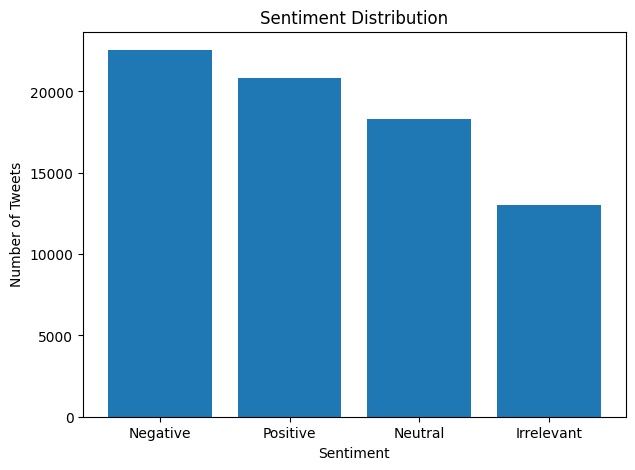

In [12]:
label_counts = df["Sentiment"].value_counts()

plt.figure(figsize=(7,5))

plt.bar(label_counts.index, label_counts.values)

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Tweets")

plt.show()

Phase 3 — Data Cleaning
Objectives
Prepare text for machine learning.

Learn
Lowercase conversion
Removing punctuation
Removing special characters
Removing numbers
Removing URLs
Removing extra spaces
Output
Clean text ready for preprocessing.

Step 1: Import Required Libraries

In [13]:
import re
import string

Step 2: Check Missing Values Again

In [14]:
df.isnull().sum()

,0
Tweet_ID,0
Entity,0
Sentiment,0
Tweet,686


Step 3: Remove Missing Tweets

In [15]:
df = df.dropna(subset=["Tweet"])

In [16]:
df.isnull().sum()


,0
Tweet_ID,0
Entity,0
Sentiment,0
Tweet,0


**Step 4: Remove "Irrelevant" Sentiment**


In [17]:
df = df[df["Sentiment"] != "Irrelevant"]

In [18]:
df["Sentiment"].value_counts()

,count
Sentiment,
Negative,22358
Positive,20655
Neutral,18108


Step 5: Create a Cleaning Function

In [19]:
def clean_text(text):

    # Convert to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r"http\S+|www\S+", "", text)

    # Remove numbers
    text = re.sub(r"\d+", "", text)

    # Remove punctuation
    text = text.translate(str.maketrans("", "", string.punctuation))

    # Remove special characters
    text = re.sub(r"[^a-zA-Z\s]", "", text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text

Step 6: Apply the Cleaning Function

In [20]:
df["Clean_Text"] = df["Tweet"].apply(clean_text)

Step 7: Compare Original vs Cleaned Text

In [21]:
df[["Tweet", "Clean_Text"]].head(10)

,Tweet,Clean_Text
0,im getting on borderlands and i will murder yo...,im getting on borderlands and i will murder yo...
1,I am coming to the borders and I will kill you...,i am coming to the borders and i will kill you...
2,im getting on borderlands and i will kill you ...,im getting on borderlands and i will kill you all
3,im coming on borderlands and i will murder you...,im coming on borderlands and i will murder you...
4,im getting on borderlands 2 and i will murder ...,im getting on borderlands and i will murder yo...
5,im getting into borderlands and i can murder y...,im getting into borderlands and i can murder y...
6,So I spent a few hours making something for fu...,so i spent a few hours making something for fu...
7,So I spent a couple of hours doing something f...,so i spent a couple of hours doing something f...
8,So I spent a few hours doing something for fun...,so i spent a few hours doing something for fun...
9,So I spent a few hours making something for fu...,so i spent a few hours making something for fu...


Step 8: Check for Empty Cleaned Text

In [22]:
(df["Clean_Text"] == "").sum()

np.int64(278)

In [23]:
df = df[df["Clean_Text"] != ""]

Step 9: Save the Cleaned Dataset

In [24]:
df.to_csv("cleaned_sentiment.csv", index=False)

Phase 4 — Text Preprocessing
Objectives
Convert human language into machine-readable format.

Learn
Tokenization
Stopword Removal
Stemming
Lemmatization
Output
Processed text suitable for feature extraction.



Step 1: Import NLTK

In [25]:
import nltk

Step 2: Download Required NLTK Resources

In [26]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

Step 3: Import NLP Modules

In [30]:
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.stem import WordNetLemmatizer
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

Step 4: Create NLP Objects

In [28]:
stop_words = set(stopwords.words("english"))

stemmer = PorterStemmer()

lemmatizer = WordNetLemmatizer()

Tokenization

In [31]:
word_tokenize("I am loving this beautiful mobile phone.")

['I', 'am', 'loving', 'this', 'beautiful', 'mobile', 'phone', '.']

Step 5: Create the Preprocessing Function

In [32]:
def preprocess_text(text):

    # Tokenization
    tokens = word_tokenize(text)

    # Remove Stopwords
    tokens = [word for word in tokens if word not in stop_words]

    # Stemming
    tokens = [stemmer.stem(word) for word in tokens]

    # Lemmatization
    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    # Join tokens back into a sentence
    return " ".join(tokens)

Step 6: Apply the Function

In [33]:
df["Processed_Text"] = df["Clean_Text"].apply(preprocess_text)

Step 7: Compare the Results

In [34]:
df[["Tweet", "Clean_Text", "Processed_Text"]].head(10)

,Tweet,Clean_Text,Processed_Text
0,im getting on borderlands and i will murder yo...,im getting on borderlands and i will murder yo...,im get borderland murder
1,I am coming to the borders and I will kill you...,i am coming to the borders and i will kill you...,come border kill
2,im getting on borderlands and i will kill you ...,im getting on borderlands and i will kill you all,im get borderland kill
3,im coming on borderlands and i will murder you...,im coming on borderlands and i will murder you...,im come borderland murder
4,im getting on borderlands 2 and i will murder ...,im getting on borderlands and i will murder yo...,im get borderland murder
5,im getting into borderlands and i can murder y...,im getting into borderlands and i can murder y...,im get borderland murder
6,So I spent a few hours making something for fu...,so i spent a few hours making something for fu...,spent hour make someth fun dont know huge bord...
7,So I spent a couple of hours doing something f...,so i spent a couple of hours doing something f...,spent coupl hour someth fun dont know im huge ...
8,So I spent a few hours doing something for fun...,so i spent a few hours doing something for fun...,spent hour someth fun dont know im huge border...
9,So I spent a few hours making something for fu...,so i spent a few hours making something for fu...,spent hour make someth fun dont know huge rhan...


Step 8: Check for Empty Processed Text

In [35]:
(df["Processed_Text"] == "").sum()

np.int64(1120)

In [36]:
df = df[df["Processed_Text"] != ""]

Step 9: Save the Processed Dataset

In [37]:
df.to_csv("processed_sentiment.csv", index=False)

Phase 5 — Feature Engineering
Objectives
Transform text into numerical vectors.

Learn
Bag of Words
TF-IDF Vectorization
Output
Numerical dataset for training

Step 1: Import TF-IDF

In [38]:
from sklearn.feature_extraction.text import TfidfVectorizer

Step 2: Create the TF-IDF Vectorizer

In [39]:
vectorizer = TfidfVectorizer(max_features=5000)

Step 3: Convert Text into Numbers

In [40]:
X = vectorizer.fit_transform(df["Processed_Text"])

Step 4: Create the Labels (Target Variable)

In [41]:
y = df["Sentiment"]

Step 5: Check the Shape of X and y


In [42]:
print("Shape of X:", X.shape)

Shape of X: (59723, 5000)


In [43]:
print("Shape of y:", y.shape)

Shape of y: (59723,)


Step 7: Display the First Few Labels

In [44]:
y.head()

,Sentiment
0,Positive
1,Positive
2,Positive
3,Positive
4,Positive


Step 8: Display the Vocabulary Size

In [45]:
print("Vocabulary Size:", len(vectorizer.vocabulary_))

Vocabulary Size: 5000


Step 9: View Some Words in the Vocabulary

In [46]:
list(vectorizer.vocabulary_.keys())[:20]

['im',
 'get',
 'borderland',
 'murder',
 'come',
 'border',
 'kill',
 'spent',
 'hour',
 'make',
 'someth',
 'fun',
 'dont',
 'know',
 'huge',
 'fan',
 'maya',
 'one',
 'favorit',
 'charact']

Step 10: View the TF-IDF Matrix

In [47]:
X

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 548845 stored elements and shape (59723, 5000)>

Step 11: Convert a Small Portion to a Table

In [48]:
tfidf_df = pd.DataFrame(
    X[:5].toarray(),
    columns=vectorizer.get_feature_names_out()
)

tfidf_df.head()

,aaa,aaron,ab,abandon,abbott,abil,abl,abnorm,aboard,absenc,...,zer,zero,zion,zip,zoe,zombi,zone,zonestreamcx,zoom,zuckerberg
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Phase 6 — Model Training
Objectives
Train your first AI model.

Learn
Train/Test Split
Supervised Learning
Classification
Suggested Algorithms
Logistic Regression
Naive Bayes
Random Forest (Optional)
Output
A trained sentiment classification model.

Step 1: Import Required Libraries

In [49]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier

Step 2: Split the Dataset

In [50]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


Step 3: Check Dataset Sizes

In [51]:
print("Training Data:", X_train.shape)
print("Testing Data :", X_test.shape)

Training Data: (47778, 5000)
Testing Data : (11945, 5000)


Step 4: Train Logistic Regression

In [52]:
logistic_model = LogisticRegression(max_iter=1000)

logistic_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

Step 5: Make Predictions

In [53]:
logistic_predictions = logistic_model.predict(X_test)

Step 6: Train Naive Bayes

In [54]:
naive_model = MultinomialNB()

naive_model.fit(X_train, y_train)

MultinomialNB()

Step 7: Predict with Naive Bayes

In [55]:
naive_predictions = naive_model.predict(X_test)

Step 10: Test the Model with Your Own Sentences

In [56]:
sample_sentences = [
    "I love this internship.",
    "This movie is terrible.",
    "The weather is normal today."
]

sample_vectors = vectorizer.transform(sample_sentences)

predictions = logistic_model.predict(sample_vectors)

for sentence, prediction in zip(sample_sentences, predictions):
    print(f"Sentence: {sentence}")
    print(f"Prediction: {prediction}")
    print("-" * 40)

Sentence: I love this internship.
Prediction: Positive
----------------------------------------
Sentence: This movie is terrible.
Prediction: Neutral
----------------------------------------
Sentence: The weather is normal today.
Prediction: Positive
----------------------------------------


Phase 7 — Model Evaluation
Objectives
Measure model performance.

Learn
Accuracy
Precision
Recall
F1 Score
Confusion Matrix
Tasks
Test model on unseen data
Compare predictions with actual labels

Step 1: Import Evaluation Libraries

In [57]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

Step 2: Evaluate Logistic Regression

In [58]:
print("========== Logistic Regression ==========")

accuracy = accuracy_score(y_test, logistic_predictions)

precision = precision_score(
    y_test,
    logistic_predictions,
    average="weighted"
)

recall = recall_score(
    y_test,
    logistic_predictions,
    average="weighted"
)

f1 = f1_score(
    y_test,
    logistic_predictions,
    average="weighted"
)

print("Accuracy :", round(accuracy,4))
print("Precision:", round(precision,4))
print("Recall   :", round(recall,4))
print("F1 Score :", round(f1,4))

========== Logistic Regression ==========
Accuracy : 0.7593
Precision: 0.7586
Recall   : 0.7593
F1 Score : 0.7588


Step 3: Print Classification Report

In [59]:
print(classification_report(
    y_test,
    logistic_predictions
))

              precision    recall  f1-score   support

    Negative       0.79      0.81      0.80      4383
     Neutral       0.71      0.69      0.70      3529
    Positive       0.77      0.76      0.77      4033

    accuracy                           0.76     11945
   macro avg       0.76      0.75      0.76     11945
weighted avg       0.76      0.76      0.76     11945



Step 4: Draw the Confusion Matrix

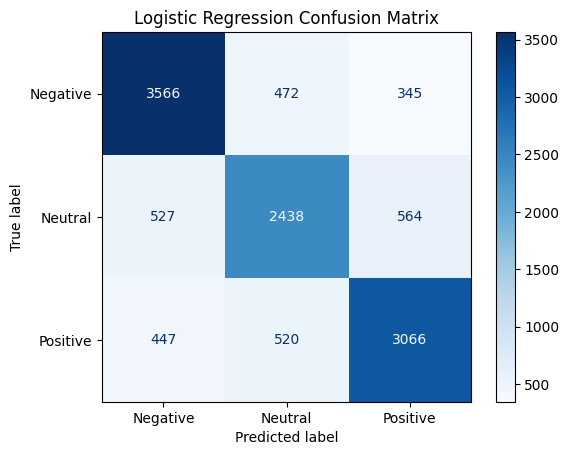

In [60]:
cm = confusion_matrix(
    y_test,
    logistic_predictions
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=logistic_model.classes_
)

disp.plot(cmap="Blues")

plt.title("Logistic Regression Confusion Matrix")

plt.show()

Step 5: Evaluate Naive Bayes

In [61]:
print("========== Naive Bayes ==========")

accuracy_nb = accuracy_score(
    y_test,
    naive_predictions
)

precision_nb = precision_score(
    y_test,
    naive_predictions,
    average="weighted"
)

recall_nb = recall_score(
    y_test,
    naive_predictions,
    average="weighted"
)

f1_nb = f1_score(
    y_test,
    naive_predictions,
    average="weighted"
)

print("Accuracy :", round(accuracy_nb,4))
print("Precision:", round(precision_nb,4))
print("Recall   :", round(recall_nb,4))
print("F1 Score :", round(f1_nb,4))

========== Naive Bayes ==========
Accuracy : 0.7262
Precision: 0.7272
Recall   : 0.7262
F1 Score : 0.722


Step 6: Naive Bayes Classification Report

In [62]:
print(classification_report(
    y_test,
    naive_predictions
))

              precision    recall  f1-score   support

    Negative       0.72      0.81      0.77      4383
     Neutral       0.74      0.57      0.64      3529
    Positive       0.72      0.77      0.75      4033

    accuracy                           0.73     11945
   macro avg       0.73      0.72      0.72     11945
weighted avg       0.73      0.73      0.72     11945



Step 7: Naive Bayes Confusion Matrix

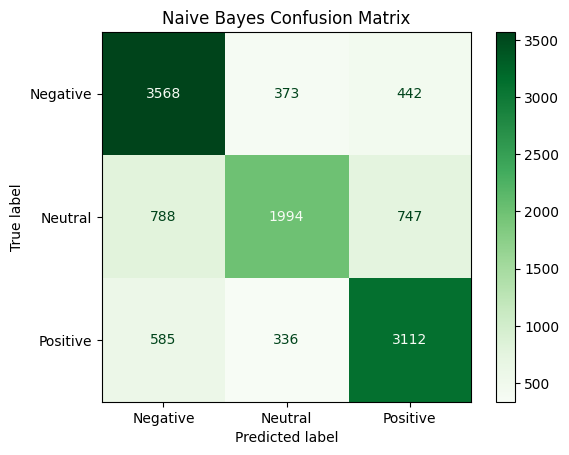

In [63]:
cm_nb = confusion_matrix(
    y_test,
    naive_predictions
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_nb,
    display_labels=naive_model.classes_
)

disp.plot(cmap="Greens")

plt.title("Naive Bayes Confusion Matrix")

plt.show()

Step 9: Compare the Models

In [64]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Naive Bayes"
    ],
    "Accuracy": [
        accuracy,
        accuracy_nb
    ],
    "Precision": [
        precision,
        precision_nb
    ],
    "Recall": [
        recall,
        recall_nb
    ],
    "F1 Score": [
        f1,
        f1_nb
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.759314,0.758626,0.759314,0.758823
1,Naive Bayes,0.726162,0.727207,0.726162,0.722033


Phase 8 — Save the Model

Step 1: Import Joblib

In [65]:
import joblib

Step 2: Save the Logistic Regression Model

In [66]:
joblib.dump(logistic_model, "model.pkl")

['model.pkl']

Step 3: Save the TF-IDF Vectorizer

In [67]:
joblib.dump(vectorizer, "vectorizer.pkl")

['vectorizer.pkl']

Step 4: Verify the Files

In [68]:
import os

print(os.listdir())

['.config', 'cleaned_sentiment.csv', 'sentiment.csv', 'processed_sentiment.csv', 'vectorizer.pkl', 'model.pkl', 'sample_data']


Step 5: Test Loading the Model

In [69]:
loaded_model = joblib.load("model.pkl")
loaded_vectorizer = joblib.load("vectorizer.pkl")

Step 6: Test the Saved Model

In [70]:
sentence = ["I really enjoyed this internship."]

sentence_vector = loaded_vectorizer.transform(sentence)

prediction = loaded_model.predict(sentence_vector)

print("Prediction:", prediction[0])

Prediction: Neutral


In [71]:
samples = [
    "This internship is amazing.",
    "I hate this product.",
    "The meeting was okay."
]

vectors = loaded_vectorizer.transform(samples)

predictions = loaded_model.predict(vectors)

for text, pred in zip(samples, predictions):
    print(f"Text: {text}")
    print(f"Prediction: {pred}")
    print("-" * 40)

Text: This internship is amazing.
Prediction: Neutral
----------------------------------------
Text: I hate this product.
Prediction: Negative
----------------------------------------
Text: The meeting was okay.
Prediction: Positive
----------------------------------------


In [72]:
samples = [
    "I love this game.",
    "This phone is terrible.",
    "The Microsoft update is good.",
    "The product quality is excellent.",
    "The service was awful.",
    "The movie was average."
]

vectors = loaded_vectorizer.transform(samples)
predictions = loaded_model.predict(vectors)

for text, pred in zip(samples, predictions):
    print(f"Text: {text}")
    print(f"Prediction: {pred}")
    print("-"*40)

Text: I love this game.
Prediction: Positive
----------------------------------------
Text: This phone is terrible.
Prediction: Negative
----------------------------------------
Text: The Microsoft update is good.
Prediction: Positive
----------------------------------------
Text: The product quality is excellent.
Prediction: Neutral
----------------------------------------
Text: The service was awful.
Prediction: Neutral
----------------------------------------
Text: The movie was average.
Prediction: Neutral
----------------------------------------
